In [1]:
#pip3 install torch torchvision
# In a conda env like machine_learning
# FOllow these steps to install sam2:
# https://github.com/facebookresearch/sam2?tab=readme-ov-file#download-checkpoints


In [3]:
# Load packagesfrom segment_anything import SamPredictor, sam_model_registry
#from segment_anything import SamPredictor, sam_model_registry
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image
import torch
import os
import torch
#from segment_anything import sam_model_registry
import cv2 
#from segment_anything import SamAutomaticMaskGenerator
import pickle
import numpy as np

import matplotlib.pyplot as plt
from PIL import Image

from PIL import ImageFilter



import os, re, csv, math
import numpy as np
import cv2
from PIL import Image
import pytesseract
from pytesseract import Output

In [4]:
using_colab = False

In [5]:
import os
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

In [6]:
if using_colab:
    import torch
    import torchvision
    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())
    import sys
    !{sys.executable} -m pip install opencv-python matplotlib
    !{sys.executable} -m pip install 'git+https://github.com/facebookresearch/sam2.git'

    #!mkdir -p images
    #!wget -P images https://raw.githubusercontent.com/facebookresearch/sam2/main/notebooks/images/cars.jpg

    #!mkdir -p ../checkpoints/
    #!wget -P ../checkpoints/ https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_large.pt

In [7]:
# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "give numerically different outputs and sometimes degraded performance on MPS. "
        "See e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion."
    )

using device: mps

Support for MPS devices is preliminary. SAM 2 is trained with CUDA and might give numerically different outputs and sometimes degraded performance on MPS. See e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion.


In [13]:
np.random.seed(3)

def show_anns(anns, borders=True):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:, :, 3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.5]])
        img[m] = color_mask 
        if borders:
            import cv2
            contours, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
            # Try to smooth contours
            contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
            cv2.drawContours(img, contours, -1, (0, 0, 1, 0.4), thickness=1) 

    ax.imshow(img)

In [15]:
image = Image.open('small_E1_H1.tif')
image = np.array(image.convert("RGB"))

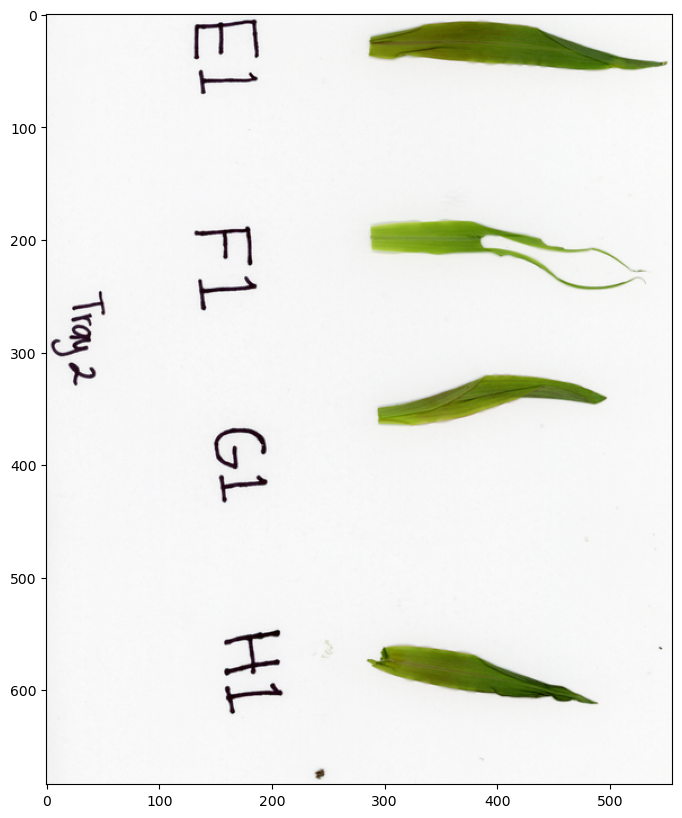

In [17]:
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis('on')
plt.show()

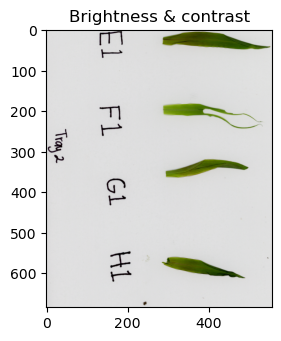

In [19]:
# Adjust the brightness and contrast
# Adjusts the brightness by adding 10 to each pixel value
brightness = -25 
# Adjusts the contrast by scaling the pixel values by 2.3
contrast = 1  
image2 = cv2.addWeighted(image, contrast, np.zeros(image.shape, image.dtype), 0, brightness)

#Plot the contrast image
plt.subplot(1, 2, 2)
plt.title("Brightness & contrast")
plt.imshow(image2)
plt.show()

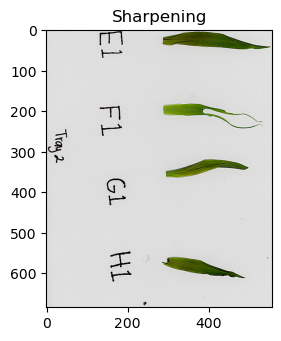

In [21]:
# Create the sharpening kernel
kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
  
# Sharpen the image
sharpened_image = cv2.filter2D(image2, -1, kernel)

#Plot the sharpened image
plt.subplot(1, 2, 2)
plt.title("Sharpening")
plt.imshow(sharpened_image)
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-444.0..435.0].


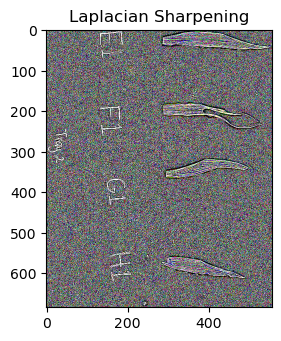

In [23]:
# Sharpen the image using the Laplacian operator
sharpened_image2 = cv2.Laplacian(image, cv2.CV_64F)
#Plot the sharpened image
plt.subplot(1, 2, 2)
plt.title("Laplacian Sharpening")
plt.imshow(sharpened_image2)
plt.show()

In [25]:
# Convert to np.uint8 or np.float32
sharpened_image2 = cv2.Laplacian(image, cv2.CV_64F)

# Convert safely to float32 (preferred for PyTorch)
sharpened_image2 = sharpened_image2.astype(np.float32)

# Or, if you want 8-bit range (0–255)
sharpened_image2 = cv2.convertScaleAbs(sharpened_image2)




# Normalize to 0 to 255
sharpened_image2 = cv2.Laplacian(image, cv2.CV_64F)

# Normalize to 0–255 and cast
sharpened_image2 = cv2.normalize(sharpened_image2, None, 0, 255, cv2.NORM_MINMAX)
sharpened_image2 = sharpened_image2.astype(np.uint8)



In [27]:
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor



#from hydra import initialize_config_module
#from hydra.core.global_hydra import GlobalHydra

#if not GlobalHydra.instance().is_initialized():
#    initialize_config_module("sam2", version_base="1.2")

In [29]:
from hydra import initialize_config_dir, compose
from hydra.core.global_hydra import GlobalHydra
from omegaconf import OmegaConf

config_dir = "/Users/nirwantandukar/Documents/Github/sam2/configs/sam2.1"

# Reset Hydra so we can re-init
GlobalHydra.instance().clear()

initialize_config_dir(config_dir=config_dir, job_name="test")
cfg = compose(config_name="sam2.1_hiera_l")
#print(OmegaConf.to_yaml(cfg))


/var/folders/fc/x_bs_jtd3x19_tzx4mjmg3xc0000gn/T/ipykernel_1412/3815241996.py:10: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  initialize_config_dir(config_dir=config_dir, job_name="test")


In [31]:
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

sam2_checkpoint = "/Users/nirwantandukar/Documents/Github/sam2/checkpoints/sam2.1_hiera_large.pt"
#model_cfg = "/Users/nirwantandukar/Documents/Github/sam2/configs/sam2.1/sam2.1_hiera_l.yaml"
model_cfg = "sam2.1_hiera_l"


sam2 = build_sam2(model_cfg, sam2_checkpoint, device=device, apply_postprocessing=False)

mask_generator = SAM2AutomaticMaskGenerator(sam2)

In [33]:
#Generate masks

masks = mask_generator.generate(sharpened_image2)

#Mask generation returns a list over masks, where each mask is a dictionary containing various data about the mask. These keys are:

#segmentation : the mask
#area : the area of the mask in pixels
#bbox : the boundary box of the mask in XYWH format
#predicted_iou : the model's own prediction for the quality of the mask
#point_coords : the sampled input point that generated this mask
#stability_score : an additional measure of mask quality
#crop_box : the crop of the image used to generate this mask in XYWH format

In [34]:
print(len(masks))
print(masks[0].keys())

10
dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])


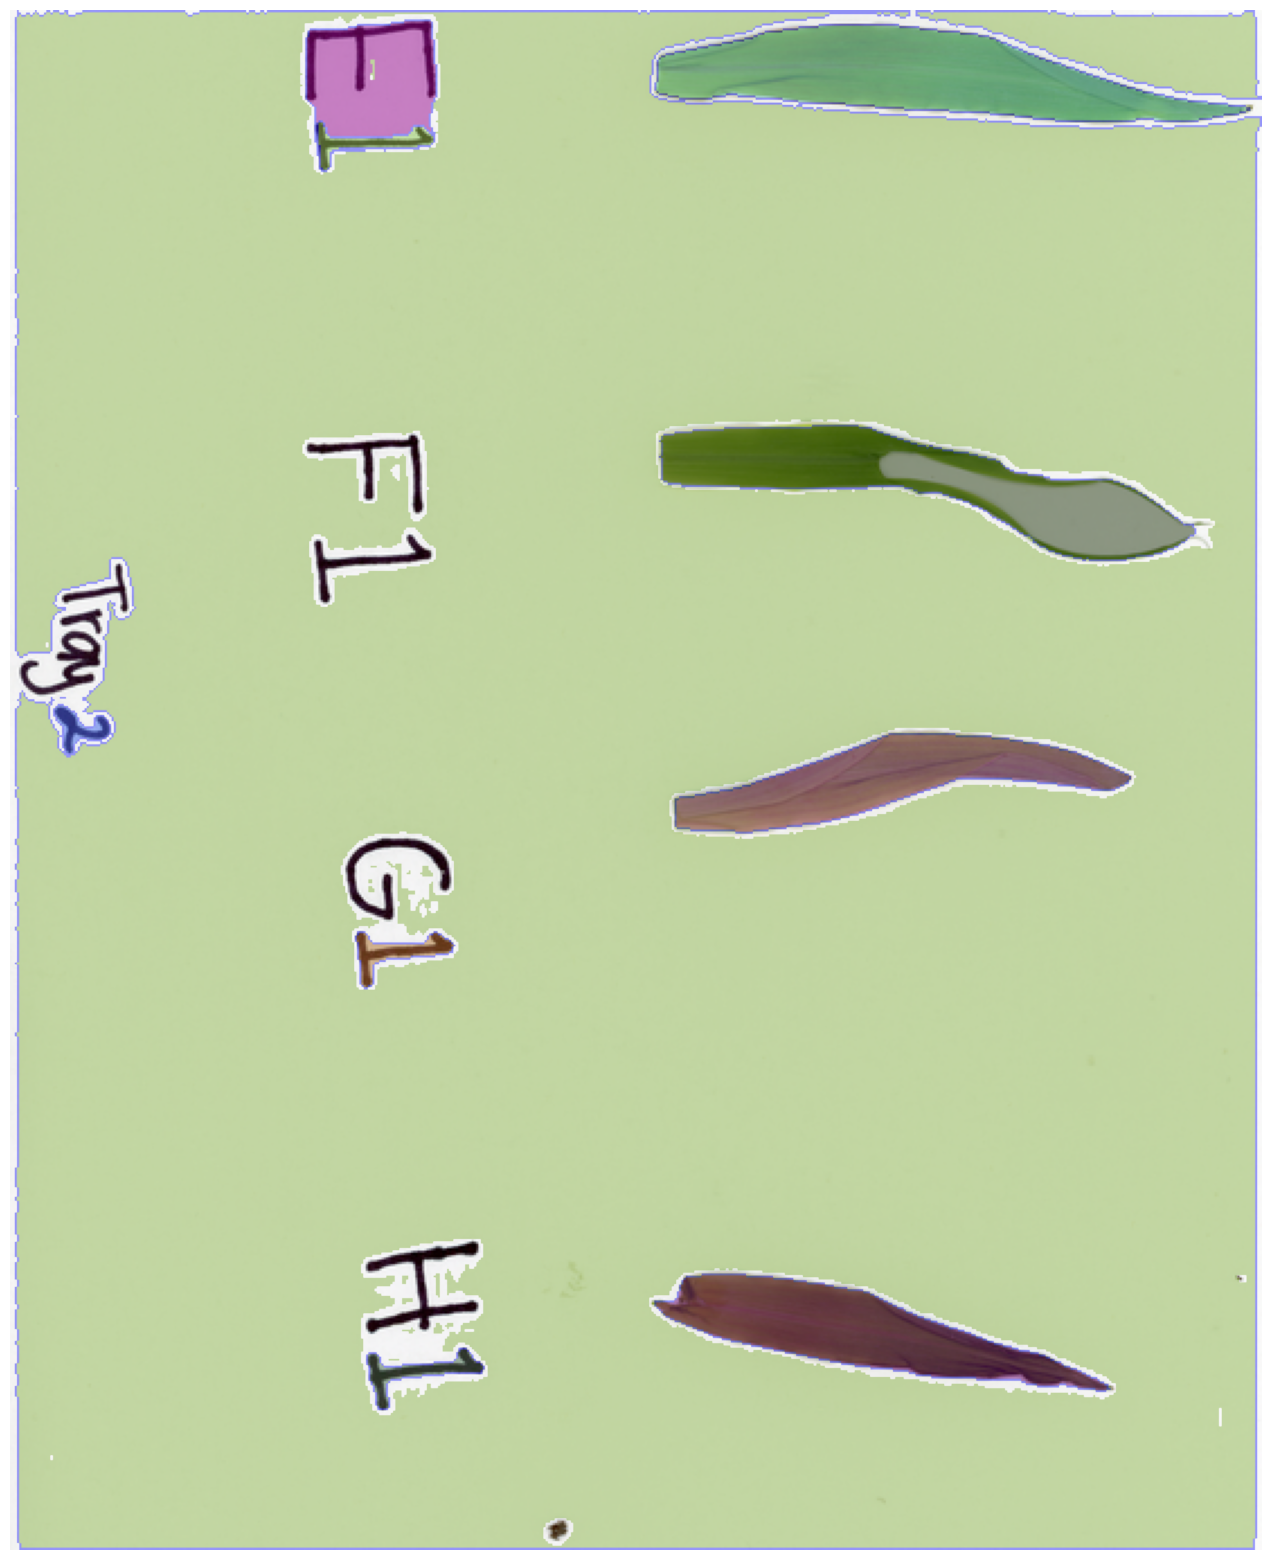

In [35]:
plt.figure(figsize=(20, 20))
plt.imshow(image)
show_anns(masks)
plt.axis('off')
plt.show() 

In [49]:
import os, csv, re
import numpy as np
import cv2
from PIL import Image

# ---------- helpers ----------
def rotate_left_90(img_rgb_uint8: np.ndarray) -> np.ndarray:
    return cv2.rotate(img_rgb_uint8, cv2.ROTATE_90_COUNTERCLOCKWISE)

def ensure_uint8_rgb(arr):
    if arr.ndim == 2:
        arr = np.stack([arr]*3, axis=-1)
    elif arr.shape[2] == 4:
        arr = cv2.cvtColor(arr, cv2.COLOR_RGBA2RGB)
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255).astype(np.uint8)
    return np.ascontiguousarray(arr)

def save_binary_mask(mask_bool, out_path):
    out = (mask_bool.astype(np.uint8) * 255)
    cv2.imwrite(out_path, out)

def preprocess_for_edges(
    img_rgb_uint8,
    brightness=0,
    contrast=1.0,
    use_unsharp=True,
    unsharp_kernel_size=9,
    unsharp_sigma=10.0,
    unsharp_amount=1.5,
    use_laplacian=False,
    gamma=None
):
    x = img_rgb_uint8.astype(np.uint8)

    if brightness != 0 or contrast != 1.0:
        x = cv2.addWeighted(x, contrast, np.zeros_like(x), 0, brightness)

    if use_unsharp:
        k = (unsharp_kernel_size, unsharp_kernel_size)
        blur = cv2.GaussianBlur(x, k, unsharp_sigma)
        x = cv2.addWeighted(x, unsharp_amount, blur, -(unsharp_amount-1.0), 0)

    if use_laplacian:
        lap = cv2.Laplacian(cv2.cvtColor(x, cv2.COLOR_RGB2GRAY), cv2.CV_64F)
        lap = cv2.normalize(lap, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        x = np.dstack([lap, lap, lap])  # SEG input only

    if gamma is not None and gamma > 0:
        tab = np.clip((np.arange(256) / 255.0) ** (1.0/gamma) * 255.0, 0, 255).astype(np.uint8)
        x = cv2.LUT(x, tab)

    return np.ascontiguousarray(x)

def save_masked_crop_rgba(image_rgb_uint8, mask_bool, bbox, out_path):
    x, y, w, h = map(int, bbox)
    x2, y2 = x + w, y + h
    x, y = max(0, x), max(0, y)
    crop_img = image_rgb_uint8[y:y2, x:x2, :]
    crop_msk = mask_bool[y:y2, x:x2]
    alpha = (crop_msk.astype(np.uint8) * 255)[..., None]
    rgba = np.dstack([crop_img, alpha])
    cv2.imwrite(out_path, cv2.cvtColor(rgba, cv2.COLOR_RGBA2BGRA))

# ---------- dedupe ----------
def mask_iou(a_bool, b_bool):
    inter = np.logical_and(a_bool, b_bool).sum()
    union = np.logical_or(a_bool, b_bool).sum() + 1e-6
    return inter / union

def dedupe_by_mask_iou(masks, iou_thresh=0.80):
    kept = []
    for m in sorted(masks, key=lambda z: z["area"], reverse=True):  # keep bigger by default
        seg = m["segmentation"].astype(bool)
        if any(mask_iou(seg, k["segmentation"].astype(bool)) > iou_thresh for k in kept):
            continue
        kept.append(m)
    return kept

# ---------- SAM2 generators ----------
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

def make_mask_generator_strong(sam2_model):
    return SAM2AutomaticMaskGenerator(
        sam2_model,
        points_per_side=32,
        points_per_batch=32,
        pred_iou_thresh=0.90,
        stability_score_thresh=0.90,
        crop_n_layers=0,
        crop_overlap_ratio=0.50,
        crop_n_points_downscale_factor=2,
        box_nms_thresh=0.7,
        min_mask_region_area=500,
        use_m2m=True,
        output_mode="binary_mask",
    )

def make_mask_generator_loose(sam2_model):
    return SAM2AutomaticMaskGenerator(
        sam2_model,
        points_per_side=128,          # denser grid
        points_per_batch=64,
        pred_iou_thresh=0.55,         # looser acceptance
        stability_score_thresh=0.60,
        crop_n_layers=1,              # add 1 scale
        crop_overlap_ratio=0.35,
        crop_n_points_downscale_factor=2,
        box_nms_thresh=0.7,
        min_mask_region_area=150,
        use_m2m=True,
        output_mode="binary_mask",
    )

# ---------- main ----------
def segment_and_save_all_masks(
    img_path,
    sam2_model,
    out_dir="masks_out",
    rotate=True,
    preproc_kwargs=None,
    close_iters=1,
    min_area_frac=0.0005,
    # new:
    run_loose_fallback=True,
    min_masks_threshold=3,           # if fewer than this after strong pass -> run loose
    merge_iou_thresh=0.60,           # bbox IoU when merging strong+loose (quick prefilter)
    dedupe_mask_iou=0.80             # final mask IoU de-dup
):
    os.makedirs(out_dir, exist_ok=True)
    if preproc_kwargs is None:
        preproc_kwargs = dict(brightness=-25, contrast=1.0, use_unsharp=True, use_laplacian=False, gamma=1.2)

    # 1) load original color
    img = np.array(Image.open(img_path))
    img = ensure_uint8_rgb(img)
    if rotate:
        img = rotate_left_90(img)
    img_color = img

    # 2) segmentation image
    img_seg = preprocess_for_edges(img_color, **preproc_kwargs)

    H, W, _ = img_seg.shape
    img_area = H * W

    # 3) strong pass
    gen_strong = make_mask_generator_strong(sam2_model)
    masks_strong = gen_strong.generate(img_seg)

    # 4) optional loose pass + merge (by bbox IoU prefilter)
    masks_all = masks_strong[:]
    if run_loose_fallback and len(masks_strong) < min_masks_threshold:
        gen_loose = make_mask_generator_loose(sam2_model)
        masks_loose = gen_loose.generate(img_seg)

        def bbox_iou_xywh(a, b):
            ax, ay, aw, ah = a; bx, by, bw, bh = b
            ax2, ay2 = ax+aw, ay+ah; bx2, by2 = bx+bw, by+bh
            ix1, iy1 = max(ax, bx), max(ay, by)
            ix2, iy2 = min(ax2, bx2), min(ay2, by2)
            iw, ih = max(0, ix2-ix1), max(0, iy2-iy1)
            inter = iw*ih
            union = aw*ah + bw*bh - inter + 1e-6
            return inter/union

        for m2 in masks_loose:
            if all(bbox_iou_xywh(m2["bbox"], m1["bbox"]) < merge_iou_thresh for m1 in masks_all):
                masks_all.append(m2)

    # 5) final de-dup by MASK IoU (stronger than bbox NMS)
    masks_final = dedupe_by_mask_iou(masks_all, iou_thresh=dedupe_mask_iou)

    # 6) save
    masks_sorted = sorted(enumerate(masks_final), key=lambda t: t[1]["area"], reverse=True)
    rows = []
    for idx, m in masks_sorted:
        if m["area"] < (min_area_frac * img_area):
            continue

        mask_bool = m["segmentation"].astype(bool)
        if close_iters and close_iters > 0:
            k = np.ones((3,3), np.uint8)
            mask_bool = cv2.morphologyEx(mask_bool.astype(np.uint8), cv2.MORPH_CLOSE, k, iterations=close_iters).astype(bool)

        bbox = m["bbox"]
        base = f"mask_{idx:03d}"

        mask_path = os.path.join(out_dir, f"{base}.png")
        save_binary_mask(mask_bool, mask_path)

        crop_path = os.path.join(out_dir, f"crop_{idx:03d}.png")
        save_masked_crop_rgba(img_color, mask_bool, bbox, crop_path)

        rows.append({
            "mask_idx": idx,
            "area_px": int(m["area"]),
            "bbox": m["bbox"],
            "mask_png": mask_path,
            "crop_png": crop_path
        })

    # 7) manifest
    csv_path = os.path.join(out_dir, "mask_manifest.csv")
    with open(csv_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["mask_idx","area_px","bbox","mask_png","crop_png"])
        writer.writeheader()
        writer.writerows(rows)

    return {
        "image_shape": (H, W),
        "num_masks_strong": len(masks_strong),
        "num_masks_final": len(masks_final),
        "num_saved": len(rows),
        "out_dir": out_dir,
        "csv": csv_path
    }


In [39]:
import os, pytesseract, shutil
# This will usually be /opt/anaconda3/envs/machine_learning/bin/tesseract
TESS_PATH = shutil.which("tesseract") or "/opt/anaconda3/envs/machine_learning/bin/tesseract"
pytesseract.pytesseract.tesseract_cmd = TESS_PATH
print("pytesseract:", pytesseract.get_tesseract_version())

pytesseract: 5.5.1


In [159]:
# Assuming you already built `sam2` and `mask_generator = SAM2AutomaticMaskGenerator(sam2)`
# and you want to process your TIFF:

res = segment_and_save_all_masks(
    img_path="maize.jpeg",
    sam2_model=sam2,
    out_dir="masks_maize_tuned",
    rotate=True,
    preproc_kwargs=dict(
        brightness=-25,  # Adds a constant to all pixels. Negative = darker, positive = brighter.
        contrast=0.8,  # Multiplies pixel values around mid-tones. >1 increases contrast, <1 flattens. Leafs vs white background: 1.0–1.2 is usually enough; too high can clip highlights on white paper.
        use_unsharp=True, # Turns on unsharp masking (edge-aware contrast boost). Great for thin blade edges.
        unsharp_kernel_size=9, # Size of the Gaussian blur used to make the unsharp mask. Bigger = affects broader structures. 7-11
        unsharp_sigma=10.0, # Blur sigma; how much to “soften” before subtracting. Higher softens more; keep ~8–12 for scanner images.
        unsharp_amount=1.5, # How strong to add the high-frequency detail back. 1.5 is a solid default. Too high → halos.
        use_laplacian=True,   # computes a Laplacian edge map (grayscale), normalizes it to 0–255, and replicates to 3 channels. This strongly emphasizes edges but discards color cues.
        gamma=1.2 # Nonlinear brightness: >1 brightens mid-tones without blowing highlights; <1 darkens mid-tones. 1.1–1.3 often perks up dull scans.
    ),
    close_iters=1,
    min_area_frac=0.0005,
    run_loose_fallback=False
)
print(res)
print("Saved masks to:", result["out_dir"])
print("CSV manifest:", result["csv"])


TypeError: segment_and_save_all_masks() got an unexpected keyword argument 'run_loose_fallback'

In [41]:
res = segment_and_save_all_masks(
    img_path="small_E2_H2.tif",
    sam2_model=sam2,
    out_dir="small_E2_H2_dup2",
    rotate=True,
    preproc_kwargs=dict(
        brightness=-25, contrast=1.0,
        use_unsharp=True, unsharp_kernel_size=9, unsharp_sigma=10.0, unsharp_amount=1.5,
        use_laplacian=False,   # start False for natural RGB pass
        gamma=1.2
    ),
    close_iters=1,
    min_area_frac=0.0005
)
print(res)


/Users/nirwantandukar/Documents/Github/sam2/sam2/sam2_image_predictor.py:431: UserWarning: cannot import name '_C' from 'sam2' (/Users/nirwantandukar/Documents/Github/sam2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  masks = self._transforms.postprocess_masks(
/Users/nirwantandukar/Documents/Github/sam2/sam2/utils/amg.py:120: UserWarning: MPS: nonzero op is not natively supported for the provided input on MacOS14Falling back on CPU. This may have performance implications.See github.com/pytorch/pytorch/issues/122916 for further info (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/mps/operations/Indexing.mm:400.)
  change_indices = diff.nonzero()


{'image_shape': (578, 692), 'num_masks_after_dedupe': 20, 'num_saved': 19, 'out_dir': 'small_E2_H2_dup2', 'csv': 'small_E2_H2_dup2/mask_manifest.csv'}


In [173]:
import os, csv, re
import numpy as np
from PIL import Image

def _load_mask_gray(mask_path):
    m = np.array(Image.open(mask_path).convert("L"))
    return (m > 0)

def _load_crop_and_mask(crop_path, mask_path=None):
    """Return (rgb_uint8, mask_bool) using crop alpha if present; else use mask_path."""
    arr = np.array(Image.open(crop_path))
    if arr.ndim == 3 and arr.shape[2] == 4:
        rgb = arr[..., :3]
        mask = arr[..., 3] > 0
        return rgb, mask
    # no alpha -> fallback to external mask; resize if shapes differ
    rgb = arr[..., :3]
    if mask_path is None:
        raise FileNotFoundError("Mask path required when crop has no alpha channel.")
    m = _load_mask_gray(mask_path).astype(np.uint8) * 255
    if m.shape[:2] != rgb.shape[:2]:
        m = np.array(Image.fromarray(m).resize((rgb.shape[1], rgb.shape[0]), Image.NEAREST))
    return rgb, (m > 0)

def _pca_major_minor(mask_bool):
    ys, xs = np.nonzero(mask_bool)
    if xs.size < 2:  # degenerate
        return 0.0, 0.0, int(xs.max()-xs.min()+1 if xs.size else 0), int(ys.max()-ys.min()+1 if ys.size else 0)
    pts = np.stack([xs, ys], axis=1).astype(np.float32)
    mu = pts.mean(axis=0, keepdims=True)
    X = pts - mu
    _, _, Vt = np.linalg.svd(X, full_matrices=False)
    V = Vt.T
    proj = X @ V
    length_major = proj[:, 0].max() - proj[:, 0].min()
    width_minor  = proj[:, 1].max() - proj[:, 1].min()
    axis_w  = xs.max() - xs.min() + 1
    axis_h  = ys.max() - ys.min() + 1
    return float(length_major), float(width_minor), int(axis_w), int(axis_h)

def _color_stats(rgb, mask_bool):
    R = rgb[..., 0][mask_bool].astype(np.float32)
    G = rgb[..., 1][mask_bool].astype(np.float32)
    B = rgb[..., 2][mask_bool].astype(np.float32)
    def stats(ch):
        if ch.size == 0:
            return dict(mean=0.0, median=0.0, sum=0.0, std=0.0)
        return dict(mean=float(ch.mean()), median=float(np.median(ch)), sum=float(ch.sum()), std=float(ch.std()))
    return stats(R), stats(G), stats(B)

def quantify_leaf_folder(
    folder="masks_E1_color",
    out_csv="phenotype_metrics.csv",
    min_area_px=50
):
    mask_files = sorted([f for f in os.listdir(folder) if re.match(r"mask_\d+\.png$", f)])
    rows = []
    for mf in mask_files:
        idx = int(re.findall(r"\d+", mf)[0])
        cf = f"crop_{idx:03d}.png"
        mask_path = os.path.join(folder, mf)
        crop_path = os.path.join(folder, cf)
        if not os.path.exists(crop_path):
            continue

        # Load crop RGB + mask (prefer crop alpha)
        rgb, mask = _load_crop_and_mask(crop_path, mask_path)
        area = int(mask.sum())
        if area < min_area_px:
            continue

        # geometry
        major_len, minor_wid, axis_w, axis_h = _pca_major_minor(mask)

        # color
        Rstats, Gstats, Bstats = _color_stats(rgb, mask)

        rows.append({
            "index": idx, "mask_png": mask_path, "crop_png": crop_path,
            "area_px2": area,
            "length_major_px": round(major_len, 2),
            "width_minor_px": round(minor_wid, 2),
            "axis_width_px": axis_w,
            "axis_height_px": axis_h,
            "mean_R": round(Rstats["mean"], 3), "mean_G": round(Gstats["mean"], 3), "mean_B": round(Bstats["mean"], 3),
            "median_R": round(Rstats["median"], 3), "median_G": round(Gstats["median"], 3), "median_B": round(Bstats["median"], 3),
            "sum_R": round(Rstats["sum"], 1), "sum_G": round(Gstats["sum"], 1), "sum_B": round(Bstats["sum"], 1),
            "std_R": round(Rstats["std"], 3), "std_G": round(Gstats["std"], 3), "std_B": round(Bstats["std"], 3),
        })

    with open(out_csv, "w", newline="") as f:
        writer = csv.DictWriter(
            f,
            fieldnames=[
                "index","mask_png","crop_png",
                "area_px2","length_major_px","width_minor_px","axis_width_px","axis_height_px",
                "mean_R","mean_G","mean_B",
                "median_R","median_G","median_B",
                "sum_R","sum_G","sum_B",
                "std_R","std_G","std_B",
            ],
        )
        writer.writeheader()
        writer.writerows(rows)

    return {"n_items": len(rows), "csv": out_csv, "examples": rows[:2]}


In [109]:
# --- Example run ---
res = quantify_leaf_folder("masks_E1_color", out_csv="phenotype_metrics.csv")
print(res)


{'n_items': 20, 'csv': 'phenotype_metrics.csv', 'examples': [{'index': 0, 'mask_png': 'masks_E1_color/mask_000.png', 'crop_png': 'masks_E1_color/crop_000.png', 'area_px2': 350869, 'length_major_px': 709.94, 'width_minor_px': 586.42, 'axis_width_px': 683, 'axis_height_px': 555, 'mean_R': 246.607, 'mean_G': 246.623, 'mean_B': 246.778, 'median_R': 248.0, 'median_G': 248.0, 'median_B': 248.0, 'sum_R': 86526872.0, 'sum_G': 86532512.0, 'sum_B': 86586872.0, 'std_R': 9.199, 'std_G': 10.056, 'std_B': 9.602}, {'index': 1, 'mask_png': 'masks_E1_color/mask_001.png', 'crop_png': 'masks_E1_color/crop_001.png', 'area_px2': 6587, 'length_major_px': 261.92, 'width_minor_px': 40.25, 'axis_width_px': 43, 'axis_height_px': 262, 'mean_R': 91.364, 'mean_G': 110.318, 'mean_B': 19.638, 'median_R': 86.0, 'median_G': 106.0, 'median_B': 11.0, 'sum_R': 601813.0, 'sum_G': 726666.0, 'sum_B': 129358.0, 'std_R': 23.457, 'std_G': 19.695, 'std_B': 28.395}]}


In [45]:
import os, csv, re
import numpy as np
import cv2
from PIL import Image

# ---------- basics ----------
def rotate_left_90(img_rgb_uint8: np.ndarray) -> np.ndarray:
    return cv2.rotate(img_rgb_uint8, cv2.ROTATE_90_COUNTERCLOCKWISE)

def ensure_uint8_rgb(arr):
    if arr.ndim == 2:
        arr = np.stack([arr]*3, axis=-1)
    elif arr.shape[2] == 4:
        arr = cv2.cvtColor(arr, cv2.COLOR_RGBA2RGB)
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255).astype(np.uint8)
    return np.ascontiguousarray(arr)

def save_binary_mask(mask_bool, out_path):
    out = (mask_bool.astype(np.uint8) * 255)
    cv2.imwrite(out_path, out)

# ---------- your original generic preproc (kept) ----------
def preprocess_for_edges(
    img_rgb_uint8,
    brightness=0,
    contrast=1.0,
    use_unsharp=True,
    unsharp_kernel_size=9,
    unsharp_sigma=10.0,
    unsharp_amount=1.5,
    use_laplacian=False,
    gamma=None
):
    x = img_rgb_uint8.astype(np.uint8)

    if brightness != 0 or contrast != 1.0:
        x = cv2.addWeighted(x, contrast, np.zeros_like(x), 0, brightness)

    if use_unsharp:
        k = (unsharp_kernel_size, unsharp_kernel_size)
        blur = cv2.GaussianBlur(x, k, unsharp_sigma)
        x = cv2.addWeighted(x, unsharp_amount, blur, -(unsharp_amount-1.0), 0)

    if use_laplacian:
        lap = cv2.Laplacian(cv2.cvtColor(x, cv2.COLOR_RGB2GRAY), cv2.CV_64F)
        lap = cv2.normalize(lap, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        x = np.dstack([lap, lap, lap])  # SEG input only

    if gamma is not None and gamma > 0:
        tab = np.clip((np.arange(256) / 255.0) ** (1.0/gamma) * 255.0, 0, 255).astype(np.uint8)
        x = cv2.LUT(x, tab)

    return np.ascontiguousarray(x)

# ---------- NEW: green-aware edge enhancer (recommended) ----------
def enhance_leaf_edges_rgb(
    img_rgb_uint8,
    hsv_h_low=25, hsv_h_high=95,    # green hue range (tweak as needed)
    hsv_s_min=40, hsv_v_min=40,
    clahe_clip=2.0, clahe_tiles=8,
    bilateral_d=7, bilateral_sigma=50,
    unsharp_amount=1.5, unsharp_sigma=10, unsharp_ksize=9,
    sobel_blend=0.12                # 0.08–0.15 is subtle/good
):
    x = img_rgb_uint8.astype(np.uint8)

    # 1) green prior in HSV (to avoid amping the white page)
    hsv = cv2.cvtColor(x, cv2.COLOR_RGB2HSV)
    h, s, v = hsv[..., 0], hsv[..., 1], hsv[..., 2]
    green = (h >= hsv_h_low) & (h <= hsv_h_high) & (s >= hsv_s_min) & (v >= hsv_v_min)
    green = cv2.morphologyEx(green.astype(np.uint8), cv2.MORPH_OPEN, np.ones((5, 5), np.uint8), iterations=1).astype(bool)

    # 2) CLAHE on entire V, then mix back only on green pixels
    clahe = cv2.createCLAHE(clipLimit=clahe_clip, tileGridSize=(clahe_tiles, clahe_tiles))
    v_clahe = clahe.apply(v)  # v is 2-D uint8
    v_eq = v.copy()
    if green.any():
        v_eq[green] = v_clahe[green]
    else:
        v_eq = v_clahe  # fallback: nothing detected as green; just use full CLAHE

    hsv2 = hsv.copy()
    hsv2[..., 2] = v_eq
    rgb_eq = cv2.cvtColor(hsv2, cv2.COLOR_HSV2RGB)

    # 3) bilateral to denoise but keep edges
    rgb_bi = cv2.bilateralFilter(rgb_eq, d=bilateral_d, sigmaColor=bilateral_sigma, sigmaSpace=bilateral_sigma)

    # 4) gentle Sobel edge injection into V channel
    gray = cv2.cvtColor(rgb_bi, cv2.COLOR_RGB2GRAY)
    sx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    sy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    sobel = cv2.normalize(cv2.magnitude(sx, sy), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    hsv3 = cv2.cvtColor(rgb_bi, cv2.COLOR_RGB2HSV)
    hsv3[..., 2] = np.clip(hsv3[..., 2].astype(np.float32) + sobel_blend * sobel, 0, 255).astype(np.uint8)
    rgb_edge = cv2.cvtColor(hsv3, cv2.COLOR_HSV2RGB)

    # 5) unsharp mask
    blur = cv2.GaussianBlur(rgb_edge, (unsharp_ksize, unsharp_ksize), unsharp_sigma)
    sharp = cv2.addWeighted(rgb_edge, unsharp_amount, blur, -(unsharp_amount - 1.0), 0)

    return np.ascontiguousarray(sharp)


# ---------- crops (always from COLOR image) ----------
def save_masked_crop_rgba(image_rgb_uint8, mask_bool, bbox, out_path):
    x, y, w, h = map(int, bbox)
    x2, y2 = x + w, y + h
    x, y = max(0, x), max(0, y)

    crop_img = image_rgb_uint8[y:y2, x:x2, :]
    crop_msk = mask_bool[y:y2, x:x2]

    alpha = (crop_msk.astype(np.uint8) * 255)[..., None]
    rgba = np.dstack([crop_img, alpha])
    cv2.imwrite(out_path, cv2.cvtColor(rgba, cv2.COLOR_RGBA2BGRA))

# ---------- de-dup by mask IoU ----------
def mask_iou(a_bool, b_bool):
    inter = np.logical_and(a_bool, b_bool).sum()
    union = np.logical_or(a_bool, b_bool).sum() + 1e-6
    return inter / union

def dedupe_by_mask_iou(masks, iou_thresh=0.80):
    kept = []
    for m in sorted(masks, key=lambda z: z["area"], reverse=True):
        seg = m["segmentation"].astype(bool)
        if any(mask_iou(seg, k["segmentation"].astype(bool)) > iou_thresh for k in kept):
            continue
        kept.append(m)
    return kept

# ---------- SAM2 generator ----------
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator
def make_mask_generator_strong(sam2_model):
    return SAM2AutomaticMaskGenerator(
        sam2_model,
        points_per_side=64,
        points_per_batch=64,
        pred_iou_thresh=0.70,
        stability_score_thresh=0.80,
        crop_n_layers=1,
        crop_overlap_ratio=0.30,
        crop_n_points_downscale_factor=2,
        box_nms_thresh=0.7,
        min_mask_region_area=200,
        use_m2m=True,
        output_mode="binary_mask",
    )

# ---------- main ----------
def segment_and_save_all_masks(
    img_path,
    sam2_model,
    out_dir="masks_out",
    rotate=True,
    # choose which preproc to use
    use_green_edge_enhance=True,
    preproc_kwargs=None,       # for preprocess_for_edges
    green_kwargs=None,         # for enhance_leaf_edges_rgb
    close_iters=1,
    min_area_frac=0.0005,
):
    os.makedirs(out_dir, exist_ok=True)

    # defaults
    if preproc_kwargs is None:
        preproc_kwargs = dict(brightness=-25, contrast=1.0, use_unsharp=True, use_laplacian=False, gamma=1.2)
    if green_kwargs is None:
        green_kwargs = dict(
            hsv_h_low=25, hsv_h_high=95, hsv_s_min=40, hsv_v_min=40,
            clahe_clip=2.0, clahe_tiles=8,
            bilateral_d=7, bilateral_sigma=50,
            unsharp_amount=1.5, unsharp_sigma=10, unsharp_ksize=9,
            sobel_blend=0.12
        )

    # 1) load original color
    img = np.array(Image.open(img_path))
    img = ensure_uint8_rgb(img)
    if rotate:
        img = rotate_left_90(img)
    img_color = img  # keep for saving crops

    # 2) build SEG image
    if use_green_edge_enhance:
        img_seg = enhance_leaf_edges_rgb(img_color, **green_kwargs)
    else:
        img_seg = preprocess_for_edges(img_color, **preproc_kwargs)

    H, W, _ = img_seg.shape
    img_area = H * W

    # 3) masks
    gen = make_mask_generator_strong(sam2_model)
    masks = gen.generate(img_seg)
    masks = dedupe_by_mask_iou(masks, iou_thresh=0.80)

    # 4) save
    masks_sorted = sorted(enumerate(masks), key=lambda t: t[1]["area"], reverse=True)
    rows = []
    for idx, m in masks_sorted:
        if m["area"] < (min_area_frac * img_area):
            continue

        mask_bool = m["segmentation"].astype(bool)
        if close_iters and close_iters > 0:
            k = np.ones((3,3), np.uint8)
            mask_bool = cv2.morphologyEx(mask_bool.astype(np.uint8), cv2.MORPH_CLOSE, k, iterations=close_iters).astype(bool)

        bbox = m["bbox"]
        base = f"mask_{idx:03d}"

        mask_path = os.path.join(out_dir, f"{base}.png")
        save_binary_mask(mask_bool, mask_path)

        crop_path = os.path.join(out_dir, f"crop_{idx:03d}.png")
        save_masked_crop_rgba(img_color, mask_bool, bbox, crop_path)

        rows.append({
            "mask_idx": idx,
            "area_px": int(m["area"]),
            "bbox": m["bbox"],
            "mask_png": mask_path,
            "crop_png": crop_path
        })

    # 5) manifest
    csv_path = os.path.join(out_dir, "mask_manifest.csv")
    with open(csv_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["mask_idx","area_px","bbox","mask_png","crop_png"])
        writer.writeheader()
        writer.writerows(rows)

    return {
        "image_shape": (H, W),
        "num_masks_after_dedupe": len(masks),
        "num_saved": len(rows),
        "out_dir": out_dir,
        "csv": csv_path
    }


In [47]:
res = segment_and_save_all_masks(
    img_path="E14_H14.tif",
    sam2_model=sam2,
    out_dir="E14_H14",
    rotate=True,
    use_green_edge_enhance=True,   # <- turn on the new enhancer
    # if you want to tweak the green enhancer:
    green_kwargs=dict(
        hsv_h_low=22, hsv_h_high=100, hsv_s_min=35, hsv_v_min=35,
        clahe_clip=2.0, clahe_tiles=8,
        bilateral_d=7, bilateral_sigma=50,
        unsharp_amount=1.4, unsharp_sigma=10, unsharp_ksize=9,
        sobel_blend=0.12
    ),
    # or fall back to your old preproc by setting use_green_edge_enhance=False
    close_iters=1,
    min_area_frac=0.0005
)
print(res)


{'image_shape': (2550, 3510), 'num_masks_after_dedupe': 30, 'num_saved': 17, 'out_dir': 'E14_H14', 'csv': 'E14_H14/mask_manifest.csv'}
